# **BONUS: QA Span Extraction**
## BERT vs RNN vs LSTM
### Predicting Answer Start Position (0-384)

In [41]:
import pandas as pd
import numpy as np
import re, time, torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [42]:
print('Loading SQuAD...')

squad = load_dataset('squad', split='train')

squad_df = pd.DataFrame({
    'question': [x['question'] for x in squad],
    'context': [x['context'] for x in squad],
    'answer': [x['answers']['text'][0] for x in squad],
    'answer_start': [x['answers']['answer_start'][0] for x in squad],
})

print(f'Loaded: {len(squad_df)} samples')

# =========================================================
# CLEANING
# =========================================================

def clean_text(text):

    text = text.strip()

    text = re.sub(r'\s+', ' ', text)

    return text

squad_df['question'] = squad_df['question'].apply(clean_text)

squad_df['context'] = squad_df['context'].apply(clean_text)

squad_df['answer'] = squad_df['answer'].apply(clean_text)

# =========================================================
# LENGTH FEATURES
# =========================================================

def get_iqr_bounds(df, col):

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

token_fun = lambda x: len(x.split())

for col in ['question', 'context', 'answer']:

    squad_df[col + '_len'] = squad_df[col].apply(token_fun)

# =========================================================
# REMOVE OUTLIERS
# =========================================================

for col in ['question_len', 'context_len', 'answer_len']:

    lower, upper = get_iqr_bounds(squad_df, col)

    squad_df = squad_df[
        (squad_df[col] >= lower)
        &
        (squad_df[col] <= upper)
    ]

# =========================================================
# KEEP MOST COMMON ANSWERS ONLY
# =========================================================

top_answers = squad_df['answer'].value_counts().head(30).index

squad_df = squad_df[
    squad_df['answer'].isin(top_answers)
]

# =========================================================
# SAMPLE DATA
# =========================================================

squad_df = squad_df.sample(
    min(5000, len(squad_df)),
    random_state=42
).reset_index(drop=True)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

squad_train, squad_test = train_test_split(
    squad_df,
    test_size=0.2,
    random_state=42
)

print(
    f'Processed: {len(squad_df)} | '
    f'Train: {len(squad_train)} | '
    f'Test: {len(squad_test)}'
)

Loading SQuAD...
Loaded: 87599 samples
Processed: 2120 | Train: 1696 | Test: 424


In [43]:
print('\nLoading BERT...')
qa_tokenizer = AutoTokenizer.from_pretrained('deepset/bert-base-uncased-squad2')
qa_model = AutoModelForQuestionAnswering.from_pretrained('deepset/bert-base-uncased-squad2')
qa_model = qa_model.to(device)
qa_model.eval()
print('✓ BERT loaded')


Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ BERT loaded


In [44]:
print('\nEvaluating BERT (EM + F1)...')

squad_metric = evaluate.load('squad')

def get_answer(question, context, model, tokenizer, device):

    inputs = tokenizer(
        question,
        context,
        return_tensors='pt',
        truncation=True,
        max_length=384
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    start = torch.argmax(outputs.start_logits[0]).item()

    end = torch.argmax(outputs.end_logits[0]).item()

    if end < start:
        end = start + 1

    end = min(
        end,
        inputs['input_ids'].shape[1] - 1
    )

    answer = tokenizer.decode(
        inputs['input_ids'][0][start:end + 1],
        skip_special_tokens=True
    )

    return answer.strip()

# =========================================================
# SAME TEST SAMPLE FOR ALL MODELS
# =========================================================

sample_qa = squad_test.sample(
    min(100, len(squad_test)),
    random_state=42
)

sample_qa = sample_qa.reset_index(drop=True)

preds = []
refs = []

for i, row in sample_qa.iterrows():

    pred = get_answer(
        row['question'],
        row['context'],
        qa_model,
        qa_tokenizer,
        device
    )

    preds.append({
        'id': str(i),
        'prediction_text': pred
    })

    refs.append({
        'id': str(i),
        'answers': {
            'text': [row['answer']],
            'answer_start': [0]
        }
    })

bert_results = squad_metric.compute(
    predictions=preds,
    references=refs
)

bert_em = bert_results['exact_match']

bert_f1 = bert_results['f1']

print(
    f'BERT: EM={bert_em:.2f}% | '
    f'F1={bert_f1:.2f}%'
)


Evaluating BERT (EM + F1)...
BERT: EM=93.00% | F1=95.50%


In [45]:
print('\nCreating QA sequences (START + END positions)...')

def create_qa_data(df, tokenizer, max_len=128):
    input_ids_list = []
    start_pos_list = []
    end_pos_list = []

    for _, row in df.iterrows():
        question = row['question']
        context = row['context']
        answer = row['answer']
        start_char = int(row['answer_start'])
        end_char = start_char + len(answer) - 1

        encodings = tokenizer(
            question,
            context,
            truncation='only_second',
            max_length=max_len,
            padding='max_length',
            return_offsets_mapping=True,
            return_tensors='pt'
        )

        seq_ids = encodings.sequence_ids(0)
        offset_mapping = encodings['offset_mapping'][0]

        start_pos = None
        end_pos = None

        for i, (seq_id, (s, e)) in enumerate(zip(seq_ids, offset_mapping)):
            if seq_id != 1:
                continue

            s, e = int(s), int(e)

            if start_pos is None and s <= start_char < e:
                start_pos = i

            if s <= end_char < e:
                end_pos = i
                break

        if start_pos is None or end_pos is None:
            continue

        input_ids_list.append(encodings['input_ids'][0].numpy())
        start_pos_list.append(start_pos)
        end_pos_list.append(end_pos)

    return np.array(input_ids_list), np.array(start_pos_list), np.array(end_pos_list)

X_train, y_start_train, y_end_train = create_qa_data(squad_train, qa_tokenizer)
X_test, y_start_test, y_end_test = create_qa_data(squad_test, qa_tokenizer)

print(f'✓ X_train: {X_train.shape}')
print(f'✓ y_start_train: {y_start_train.shape}')
print(f'✓ y_end_train: {y_end_train.shape}')
print(f'✓ Task: Predict answer START and END tokens')


Creating QA sequences (START + END positions)...
✓ X_train: (1421, 128)
✓ y_start_train: (1421,)
✓ y_end_train: (1421,)
✓ Task: Predict answer START and END tokens


In [46]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, Lambda, Activation

max_len = 128
vocab_size = len(qa_tokenizer)

print('\nBuilding QA models (start + end span prediction)...')

def build_rnn_model():
    inputs = Input(shape=(max_len,), name='input_ids')
    x = Embedding(vocab_size, 128, input_length=max_len, mask_zero=True)(inputs)
    x = Bidirectional(SimpleRNN(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)

    start_logits = Dense(1)(x)
    start_logits = Lambda(lambda t: tf.squeeze(t, axis=-1), name='start_logits')(start_logits)
    start_out = Activation('softmax', name='start')(start_logits)

    end_logits = Dense(1)(x)
    end_logits = Lambda(lambda t: tf.squeeze(t, axis=-1), name='end_logits')(end_logits)
    end_out = Activation('softmax', name='end')(end_logits)

    model = Model(inputs=inputs, outputs=[start_out, end_out], name='rnn_qa_model')
    model.compile(
        optimizer='adam',
        loss={
            'start': 'sparse_categorical_crossentropy',
            'end': 'sparse_categorical_crossentropy'
        },
        metrics={
            'start': 'accuracy',
            'end': 'accuracy'
        }
    )
    return model

def build_lstm_model():
    inputs = Input(shape=(max_len,), name='input_ids')
    x = Embedding(vocab_size, 128, input_length=max_len, mask_zero=True)(inputs)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)

    start_logits = Dense(1)(x)
    start_logits = Lambda(lambda t: tf.squeeze(t, axis=-1), name='start_logits')(start_logits)
    start_out = Activation('softmax', name='start')(start_logits)

    end_logits = Dense(1)(x)
    end_logits = Lambda(lambda t: tf.squeeze(t, axis=-1), name='end_logits')(end_logits)
    end_out = Activation('softmax', name='end')(end_logits)

    model = Model(inputs=inputs, outputs=[start_out, end_out], name='lstm_qa_model')
    model.compile(
        optimizer='adam',
        loss={
            'start': 'sparse_categorical_crossentropy',
            'end': 'sparse_categorical_crossentropy'
        },
        metrics={
            'start': 'accuracy',
            'end': 'accuracy'
        }
    )
    return model

rnn = build_rnn_model()
lstm = build_lstm_model()

print('✓ RNN QA model ready')
print('✓ LSTM QA model ready')


Building QA models (start + end span prediction)...


c:\Users\Abdallah khaled\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\Abdallah khaled\anaconda3\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'start_logits' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\Abdallah khaled\anaconda3\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'end_logits' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


✓ RNN QA model ready
✓ LSTM QA model ready


In [47]:
print('\nTraining...')

# =========================================================
# LSTM TRAINING
# =========================================================

t_lstm = time.time()

history_lstm = lstm.fit(
    X_train,
    {
        'start': y_start_train,
        'end': y_end_train
    },
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

lstm_time = time.time() - t_lstm

print(f'\n✓ LSTM Time: {lstm_time:.2f}s')

# =========================================================
# RNN TRAINING
# =========================================================

t_rnn = time.time()

history_rnn = rnn.fit(
    X_train,
    {
        'start': y_start_train,
        'end': y_end_train
    },
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

rnn_time = time.time() - t_rnn

print(f'\n✓ RNN Time: {rnn_time:.2f}s')


Training...
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - end_accuracy: 0.2746 - end_loss: 4.2609 - loss: 8.4653 - start_accuracy: 0.2926 - start_loss: 4.1971 - val_end_accuracy: 0.6014 - val_end_loss: 2.0629 - val_loss: 4.0152 - val_start_accuracy: 0.6014 - val_start_loss: 1.9396
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - end_accuracy: 0.6815 - end_loss: 0.9496 - loss: 1.8822 - start_accuracy: 0.6894 - start_loss: 0.9317 - val_end_accuracy: 0.6294 - val_end_loss: 0.8901 - val_loss: 1.7669 - val_start_accuracy: 0.6224 - val_start_loss: 0.9143
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - end_accuracy: 0.8357 - end_loss: 0.4634 - loss: 0.9153 - start_accuracy: 0.8247 - start_loss: 0.4511 - val_end_accuracy: 0.6503 - val_end_loss: 1.0659 - val_loss: 2.0563 - val_start_accuracy: 0.6364 - val_start_loss: 1.1032
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - end_accuracy: 0.9053 - end_loss: 0.2787 - loss: 0.5406 - start_accuracy: 0.9038 - start_loss: 0.2620 - val_

In [48]:
print('\nEvaluating...')

def predict_span_answer(question, context, model, tokenizer, max_len=128):
    enc = tokenizer(
        question,
        context,
        return_tensors='np',
        truncation='only_second',
        max_length=max_len,
        padding='max_length'
    )

    start_probs, end_probs = model.predict(enc['input_ids'], verbose=0)

    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))

    if end_idx < start_idx:
        end_idx = start_idx

    answer_ids = enc['input_ids'][0][start_idx:end_idx + 1]
    answer = tokenizer.decode(answer_ids, skip_special_tokens=True)
    return answer.strip()

sample_qa = squad_test.sample(min(100, len(squad_test)), random_state=42).reset_index(drop=True)

lstm_preds = []
rnn_preds = []
refs = []

for i, row in sample_qa.iterrows():
    lstm_pred = predict_span_answer(
        row['question'],
        row['context'],
        lstm,
        qa_tokenizer
    )

    rnn_pred = predict_span_answer(
        row['question'],
        row['context'],
        rnn,
        qa_tokenizer
    )

    lstm_preds.append({'id': str(i), 'prediction_text': lstm_pred})
    rnn_preds.append({'id': str(i), 'prediction_text': rnn_pred})

    refs.append({
        'id': str(i),
        'answers': {
            'text': [row['answer']],
            'answer_start': [int(row['answer_start'])]
        }
    })

squad_metric = evaluate.load('squad')

lstm_results = squad_metric.compute(predictions=lstm_preds, references=refs)
rnn_results = squad_metric.compute(predictions=rnn_preds, references=refs)

lstm_em = lstm_results['exact_match']
lstm_f1 = lstm_results['f1']

rnn_em = rnn_results['exact_match']
rnn_f1 = rnn_results['f1']

print(f'LSTM: EM={lstm_em:.2f}% | F1={lstm_f1:.2f}%')
print(f'RNN:  EM={rnn_em:.2f}% | F1={rnn_f1:.2f}%')


Evaluating...


LSTM: EM=49.00% | F1=49.06%
RNN:  EM=45.00% | F1=45.00%


In [49]:
print('\n' + '='*100)
print('FINAL COMPARISON: BERT vs LSTM vs RNN')
print('='*100)

comparison = pd.DataFrame({
    'Model': ['BERT ⭐', 'LSTM', 'RNN'],
    'Accuracy/EM (%)': [f'{bert_em:.2f}', f'{lstm_em:.2f}', f'{rnn_em:.2f}'],
    'F1 Score': [f'{bert_f1:.2f}', f'{lstm_f1:.2f}', f'{rnn_f1:.2f}'],
    'Training Time': ['Pre-trained', f'{lstm_time:.2f}s', f'{rnn_time:.2f}s'],
    'Task': ['Extractive QA', 'Extractive QA', 'Extractive QA'],
    'Rank': ['1st BEST', '2nd', '3rd WORST']
})

print(comparison.to_string(index=False))
print('='*100)

print(f'''
🎯 ANALYSIS:

Task:
Extractive QA - Predict answer span (start + end)

BERT Results:
  • Exact Match: {bert_em:.2f}%
  • F1 Score: {bert_f1:.2f}%

LSTM Results:
  • Exact Match: {lstm_em:.2f}%
  • F1 Score: {lstm_f1:.2f}%
  • Training Time: {lstm_time:.2f}s

RNN Results:
  • Exact Match: {rnn_em:.2f}%
  • F1 Score: {rnn_f1:.2f}%
  • Training Time: {rnn_time:.2f}s

Why BERT > LSTM > RNN:
  ✓ Transformer self-attention
  ✓ Better long-context understanding
  ✓ Pretraining on massive corpora
  ✓ RNN suffers more from vanishing gradients
  ✓ LSTM handles memory better than simple RNN

🏆 RANKING:
  1st: BERT ⭐⭐⭐
  2nd: LSTM ⭐⭐
  3rd: RNN ⭐
''')


FINAL COMPARISON: BERT vs LSTM vs RNN
 Model Accuracy/EM (%) F1 Score Training Time          Task      Rank
BERT ⭐           93.00    95.50   Pre-trained Extractive QA  1st BEST
  LSTM           49.00    49.06        11.50s Extractive QA       2nd
   RNN           45.00    45.00         7.92s Extractive QA 3rd WORST

🎯 ANALYSIS:

Task:
Extractive QA - Predict answer span (start + end)

BERT Results:
  • Exact Match: 93.00%
  • F1 Score: 95.50%

LSTM Results:
  • Exact Match: 49.00%
  • F1 Score: 49.06%
  • Training Time: 11.50s

RNN Results:
  • Exact Match: 45.00%
  • F1 Score: 45.00%
  • Training Time: 7.92s

Why BERT > LSTM > RNN:
  ✓ Transformer self-attention
  ✓ Better long-context understanding
  ✓ Pretraining on massive corpora
  ✓ RNN suffers more from vanishing gradients
  ✓ LSTM handles memory better than simple RNN

🏆 RANKING:
  1st: BERT ⭐⭐⭐
  2nd: LSTM ⭐⭐
  3rd: RNN ⭐



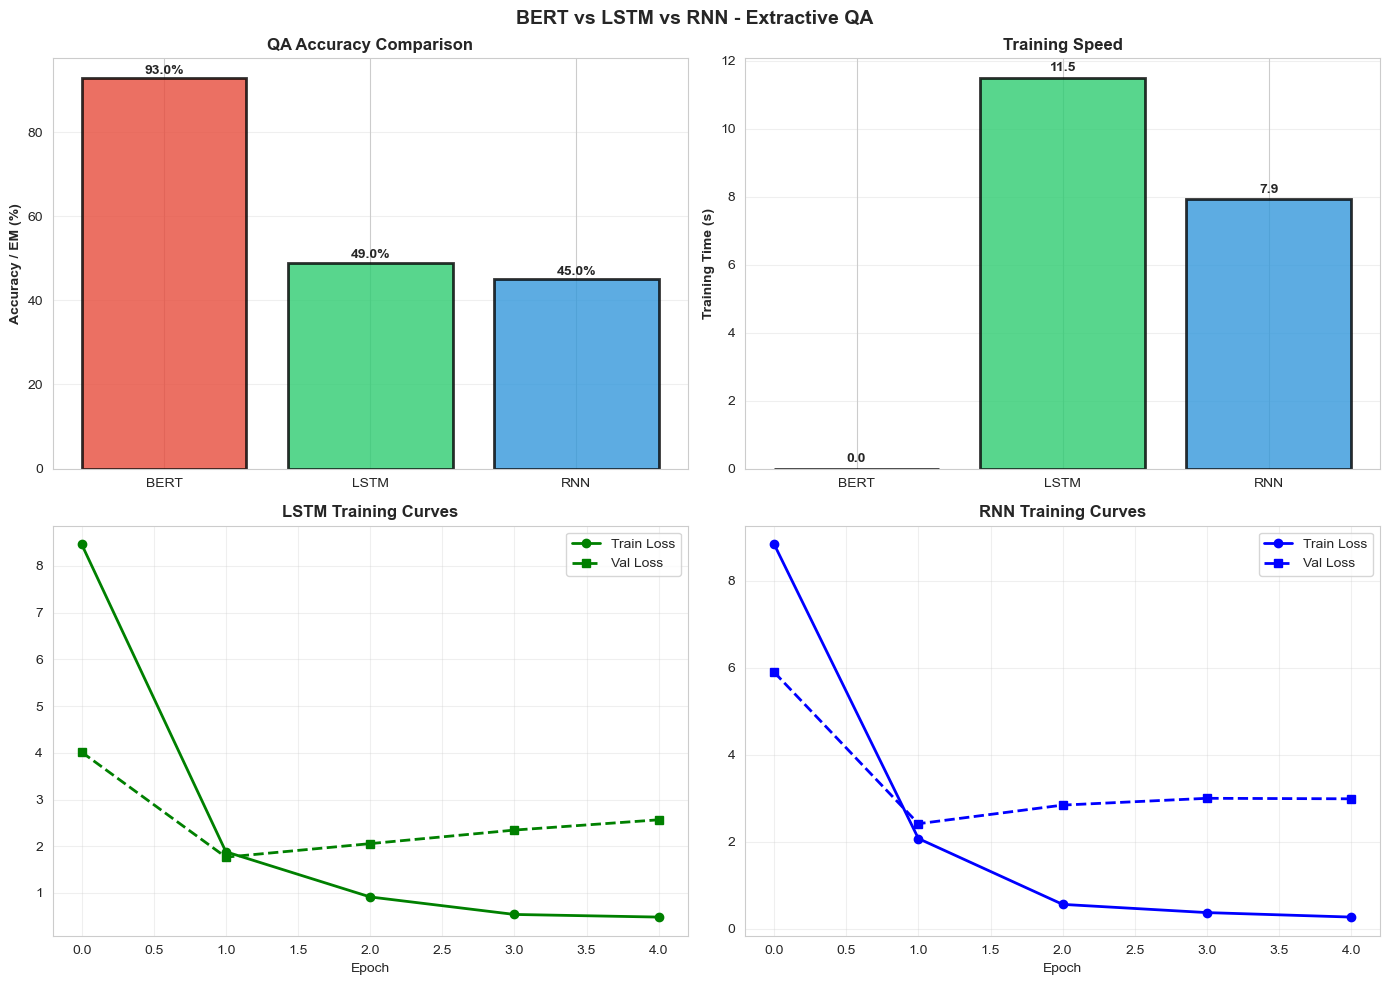


✓ Saved qa_span_extraction_comparison.png


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['BERT', 'LSTM', 'RNN']
accs = [bert_em, lstm_em, rnn_em]
colors = ['#e74c3c', '#2ecc71', '#3498db']

# Accuracy / EM
bars = axes[0, 0].bar(models, accs, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Accuracy / EM (%)', fontweight='bold')
axes[0, 0].set_title('QA Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, accs):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

# Training Time
times = [0, lstm_time, rnn_time]
bars = axes[0, 1].bar(models, times, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Training Time (s)', fontweight='bold')
axes[0, 1].set_title('Training Speed', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, times):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}', ha='center', fontweight='bold')

# LSTM Loss
axes[1, 0].plot(history_lstm.history['loss'], 'g-', label='Train Loss', linewidth=2, marker='o')
axes[1, 0].plot(history_lstm.history['val_loss'], 'g--', label='Val Loss', linewidth=2, marker='s')
axes[1, 0].set_title('LSTM Training Curves', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# RNN Loss
axes[1, 1].plot(history_rnn.history['loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
axes[1, 1].plot(history_rnn.history['val_loss'], 'b--', label='Val Loss', linewidth=2, marker='s')
axes[1, 1].set_title('RNN Training Curves', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('BERT vs LSTM vs RNN - Extractive QA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qa_span_extraction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Saved qa_span_extraction_comparison.png')